# 02 — Prompt comparison
### Comparer baseline_prompt.txt et improved_prompt.txt sur les mêmes cas.
Mini batch check (sample d'image) pour vérifier la pertinence du model

## 1. Set up
### Import des libraries

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from src.inference import vlm_predict_placeholder
from src.guardrails import apply_safety_guardrails

c:\Users\auber.MSI\Projets\TD-Mastercamp\SolutionDelivery\Assistant-Radiologique-Virtuel-Intelligent-pour-Radiographies-X\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Check le nombre d'images disponibles et le temps pour tester le modèle

In [2]:
data_root = Path('../data')
folder = 'brutes'
total = len(list((data_root / folder).glob('*.jpg')))
print(f"Total images : {total}")
print(f"Temps estimé VLM : ~{total * 40 // 60} minutes")

Total images : 932
Temps estimé VLM : ~621 minutes


## 2. Mini batch
### Resultat du mini batch extraits de `results\ batch_results.csv`
Run avec le fichier : `scripts\run_batch.py` (30 cas pour éviter les problèmes de gpu)

In [3]:
# print batch_results.csv saved under results directory as csvfile
df_final = pd.read_csv('../results/batch_results.csv')
display(df_final)

,case_id,file,path,folder,ground_truth,toy_class,toy_confidence,vlm_baseline_class,vlm_baseline_confidence,vlm_improved_class,vlm_improved_confidence
0,1,NORMAL-LUNG_00115_normal_142.jpg,data\normal_lung_probe\NORMAL-LUNG_00115_norma...,normal_lung_probe,normal,normal,0.743,normal,0.95,normal,0.8
1,2,NORMAL-LUNG_00026_normal_036.jpg,data\normal_lung_probe\NORMAL-LUNG_00026_norma...,normal_lung_probe,normal,normal,0.730,normal,0.95,normal,0.8
2,3,NORMAL-LUNG_00282_normal_320.jpg,data\normal_lung_probe\NORMAL-LUNG_00282_norma...,normal_lung_probe,normal,normal,0.752,normal,0.95,normal,0.8
3,4,NORMAL-LUNG_00251_normal_285.jpg,data\normal_lung_probe\NORMAL-LUNG_00251_norma...,normal_lung_probe,normal,normal,0.728,normal,0.95,normal,0.8
4,5,NORMAL-LUNG_00229_normal_262.jpg,data\normal_lung_probe\NORMAL-LUNG_00229_norma...,normal_lung_probe,normal,normal,0.739,normal,0.95,normal,0.8
5,6,ABNORMAL-LUNG_00143_suspected_opacity_152.jpg,data\lung_images\ABNORMAL-LUNG_00143_suspected...,lung_images,suspected_opacity,suspected_opacity,0.704,normal,0.95,normal,0.8
6,7,NORMAL-LUNG_00755_normal_374.jpg,data\lung_images\NORMAL-LUNG_00755_normal_374.jpg,lung_images,normal,normal,0.731,normal,0.80,normal,0.8
7,8,ABNORMAL-LUNG_00105_suspected_opacity_112.jpg,data\lung_images\ABNORMAL-LUNG_00105_suspected...,lung_images,suspected_opacity,suspected_opacity,0.717,suspected_opacity,0.30,normal,0.8
8,9,NORMAL-LUNG_00693_normal_308.jpg,data\lung_images\NORMAL-LUNG_00693_normal_308.jpg,lung_images,normal,normal,0.747,normal,0.95,normal,0.8
9,10,NORMAL-LUNG_00759_normal_378.jpg,data\lung_images\NORMAL-LUNG_00759_normal_378.jpg,lung_images,normal,normal,0.714,normal,0.95,normal,0.8


### Calculs des métriques pour la comparaison


=== VLM Baseline ===
Total : 15
Taux uncertain    : 6.7%
Accuracy : 60.0%
Macro F1 : 0.337
Sensibilité : 14.3%
Spécificité : 61.5%


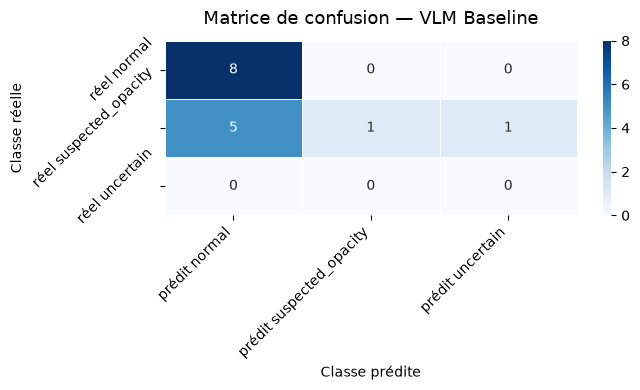


=== VLM Improved ===
Total : 15
Taux uncertain    : 0.0%
Accuracy : 53.3%
Macro F1 : 0.232
Sensibilité : 0.0%
Spécificité : 53.3%


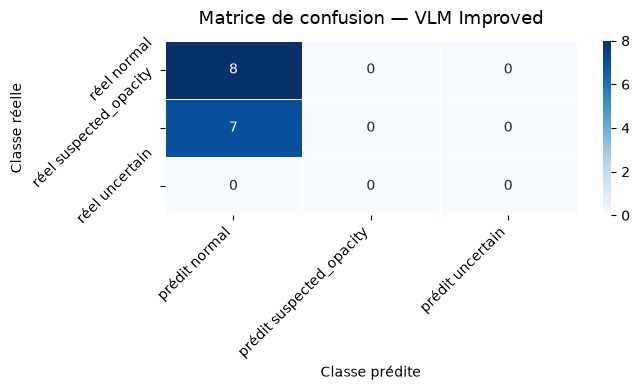

In [4]:
from src.metrics import summarize_metrics, confusion_matrix_numpy

df_final = pd.read_csv('../results/batch_results.csv')

CLASSES = ['normal', 'suspected_opacity', 'uncertain']
modes = {
    'VLM Baseline': 'vlm_baseline_class',
    'VLM Improved': 'vlm_improved_class',
}

for label, col in modes.items():
    print(f"\n=== {label} ===")
    valid = df_final[df_final[col].notna() & (df_final[col] != 'error')].copy()

    # Métriques globales (uncertain inclus)
    rows = [{"label": t, "predicted_class": p, "warning": True}
            for t, p in zip(valid['ground_truth'], valid[col])]
    m = summarize_metrics(rows)
    print(f"Total : {m['n']}")
    print(f"Taux uncertain    : {m['uncertain_rate']:.1%}")
    print(f"Accuracy : {m['accuracy']:.1%}")
    print(f"Macro F1 : {m['macro_f1']:.3f}")
    print(f"Sensibilité : {m['sensitivity']:.1%}")
    print(f"Spécificité : {m['specificity']:.1%}")

    # Matrice de confusion
    cm = confusion_matrix_numpy(valid['ground_truth'], valid[col], CLASSES)
    cm_df = pd.DataFrame(cm,
        index=[f'réel {c}' for c in CLASSES],
        columns=[f'prédit {c}' for c in CLASSES])

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
    ax.set_title(f'Matrice de confusion — {label}', fontsize=13, pad=12)
    ax.set_ylabel('Classe réelle')
    ax.set_xlabel('Classe prédite')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 3. Résultats des runs sauvegardés dans la database

### Affichage de la table à étudier (join run et evaluation)

In [3]:
# Chemin vers la DB
DB_PATH = Path('../data/database.sqlite')

In [4]:
from src.database import get_evaluations

rows = get_evaluations(DB_PATH)
df = pd.DataFrame(rows)

df.head()


,case_id,run_id,evaluation_id,prompt_id,prompt_name,prompt_version,ground_truth_label,predicted_class,confidence,latency
0,17,1,1,1,baseline,v0,suspected_opacity,normal,0.95,52971
1,29,83,83,1,baseline,v0,suspected_opacity,normal,0.95,35864
2,34,50,50,1,baseline,v0,suspected_opacity,normal,0.95,39044
3,37,55,55,1,baseline,v0,suspected_opacity,normal,0.80,44824
4,72,62,62,1,baseline,v0,suspected_opacity,normal,0.95,35904


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   case_id             250 non-null    int64  
 1   run_id              250 non-null    int64  
 2   evaluation_id       250 non-null    int64  
 3   prompt_id           250 non-null    int64  
 4   prompt_name         250 non-null    str    
 5   prompt_version      250 non-null    str    
 6   ground_truth_label  250 non-null    str    
 7   predicted_class     250 non-null    str    
 8   confidence          250 non-null    float64
 9   latency             250 non-null    int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 26.6 KB


In [8]:
# Improved prompt
df_version = df[df['prompt_id'] == 2 ]
df_version

,case_id,run_id,evaluation_id,prompt_id,prompt_name,prompt_version,ground_truth_label,predicted_class,confidence,latency
100,17,101,101,2,improved,v1,suspected_opacity,normal,0.8,32854
101,29,183,183,2,improved,v1,suspected_opacity,normal,0.8,33556
102,34,150,150,2,improved,v1,suspected_opacity,normal,0.8,40038
103,37,155,155,2,improved,v1,suspected_opacity,normal,0.8,40375
104,72,162,162,2,improved,v1,suspected_opacity,normal,0.8,33489
...,...,...,...,...,...,...,...,...,...,...
195,849,159,159,2,improved,v1,normal,normal,0.8,37080
196,852,182,182,2,improved,v1,normal,normal,0.8,41933
197,879,130,130,2,improved,v1,normal,normal,0.8,41835
198,884,195,195,2,improved,v1,normal,normal,0.8,39508



=== VLM baseline 0 ===
Total : 100
Taux uncertain : 17.0%
Accuracy : 53.0%
Macro F1 : 0.311
Sensibilité : 10.0%
Spécificité : 61.5%


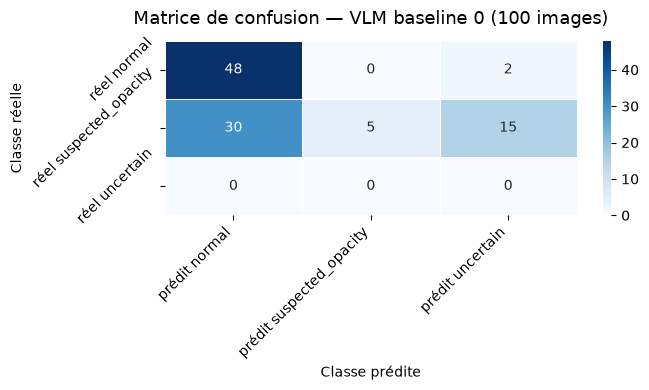


=== VLM improved 1 ===
Total : 100
Taux uncertain : 1.0%
Accuracy : 50.0%
Macro F1 : 0.224
Sensibilité : 0.0%
Spécificité : 50.5%


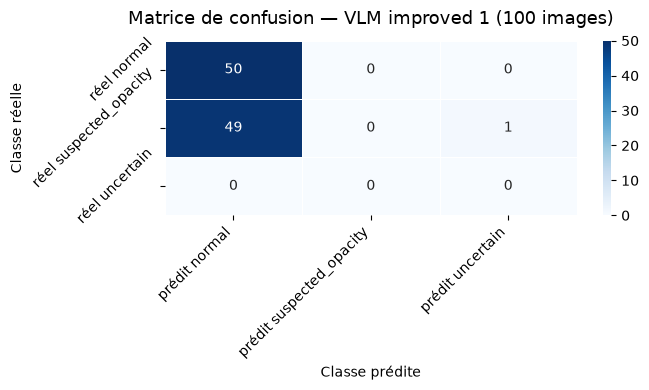


=== VLM improved 2 ===
Total : 24
Taux uncertain : 0.0%
Accuracy : 50.0%
Macro F1 : 0.222
Sensibilité : 0.0%
Spécificité : 50.0%


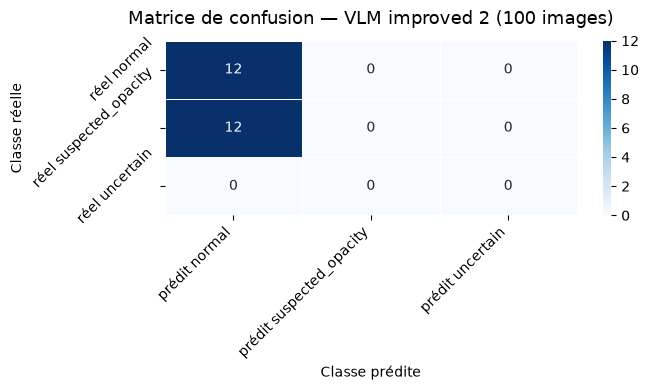


=== VLM improved 3 ===
Total : 26
Taux uncertain : 0.0%
Accuracy : 65.4%
Macro F1 : 0.436
Sensibilité : 57.1%
Spécificité : 60.0%


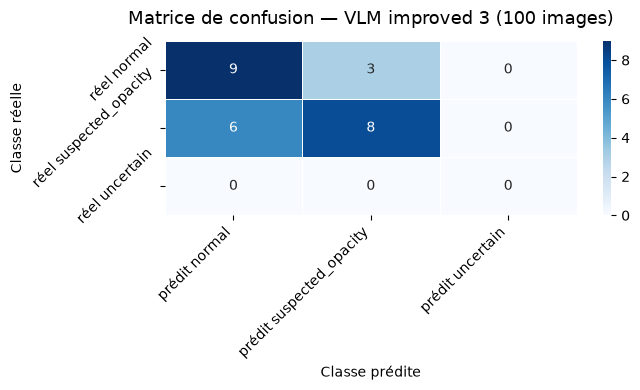

In [9]:
from src.metrics import sensitivity, specificity, confusion_matrix_numpy

CLASSES = ['normal', 'suspected_opacity', 'uncertain']

def compute_metrics_df(df, gt_col='ground_truth_label', pred_col='predicted_class'):
    valid = df.dropna(subset=[gt_col, pred_col])
    n = len(valid)
    accuracy = (valid[gt_col] == valid[pred_col]).mean()
    uncertain_rate = (valid[pred_col] == 'uncertain').mean()

    cm = confusion_matrix_numpy(valid[gt_col], valid[pred_col], CLASSES)
    
    f1_scores = []
    for i, cls in enumerate(CLASSES):
        tp = cm[i][i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        f1_scores.append(f1)
    macro_f1 = sum(f1_scores) / len(f1_scores)

    return {
        'n': n,
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'sensitivity': sensitivity(valid[gt_col], valid[pred_col]),
        'specificity': specificity(valid[gt_col], valid[pred_col]),
        'uncertain_rate': uncertain_rate,
    }
prompts = {0: "baseline", 1: "improved", 2:"improved", 3:"improved"}

for version in prompts :
    df_version = df[df['prompt_id'] == version +1 ]
    # print(df_version)
    
    PROMPT_NAME = prompts[version]
    PROMPT_VERSION = version

    m = compute_metrics_df(df_version)

    print(f'\n=== VLM {PROMPT_NAME} {PROMPT_VERSION} ===')
    print(f'Total : {m["n"]}')
    print(f'Taux uncertain : {m["uncertain_rate"]:.1%}')
    print(f'Accuracy : {m["accuracy"]:.1%}')
    print(f'Macro F1 : {m["macro_f1"]:.3f}')
    print(f'Sensibilité : {m["sensitivity"]:.1%}')
    print(f'Spécificité : {m["specificity"]:.1%}')

    # Matrice de confusion
    cm = confusion_matrix_numpy(df_version['ground_truth_label'], df_version['predicted_class'], CLASSES)
    cm_df = pd.DataFrame(cm,
        index=[f'réel {c}' for c in CLASSES],
        columns=[f'prédit {c}' for c in CLASSES])

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
    ax.set_title(f'Matrice de confusion — VLM {PROMPT_NAME} {PROMPT_VERSION} (100 images)', fontsize=13, pad=12)
    ax.set_ylabel('Classe réelle')
    ax.set_xlabel('Classe prédite')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [10]:
df_version = df[df['prompt_id'] == 3 ]
df_version

,case_id,run_id,evaluation_id,prompt_id,prompt_name,prompt_version,ground_truth_label,predicted_class,confidence,latency
200,1,212,212,3,improved,v2,suspected_opacity,normal,0.8,39354
201,5,213,213,3,improved,v2,suspected_opacity,normal,0.8,36195
202,12,214,214,3,improved,v2,suspected_opacity,normal,0.8,36402
203,17,201,201,3,improved,v2,suspected_opacity,normal,0.8,52288
204,18,221,221,3,improved,v2,suspected_opacity,normal,0.8,42063
205,19,222,222,3,improved,v2,suspected_opacity,normal,0.8,40502
206,42,215,215,3,improved,v2,suspected_opacity,normal,0.8,35247
207,53,207,207,3,improved,v2,suspected_opacity,normal,0.8,42279
208,72,206,206,3,improved,v2,suspected_opacity,normal,0.8,35388
209,347,211,211,3,improved,v2,suspected_opacity,normal,0.8,42113


In [11]:
df_version = df[df['prompt_id'] == 4 ]
df_version

,case_id,run_id,evaluation_id,prompt_id,prompt_name,prompt_version,ground_truth_label,predicted_class,confidence,latency
224,7,253,253,4,improved,v3,suspected_opacity,normal,0.85,44349
225,14,237,237,4,improved,v3,suspected_opacity,normal,0.85,39135
226,16,231,231,4,improved,v3,suspected_opacity,normal,0.85,35388
227,18,225,225,4,improved,v3,suspected_opacity,suspected_opacity,0.75,62959
228,19,226,226,4,improved,v3,suspected_opacity,suspected_opacity,0.75,57847
229,48,240,240,4,improved,v3,suspected_opacity,suspected_opacity,0.75,34653
230,65,254,254,4,improved,v3,suspected_opacity,normal,0.85,33824
231,102,246,246,4,improved,v3,suspected_opacity,normal,0.85,35729
232,112,247,247,4,improved,v3,suspected_opacity,suspected_opacity,0.75,43512
233,120,251,251,4,improved,v3,suspected_opacity,suspected_opacity,0.75,41896


## 2. Analyse des erreurs 

### Biais de luminosité ?

C:\Users\auber.MSI\AppData\Local\Temp\ipykernel_5928\3653602463.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


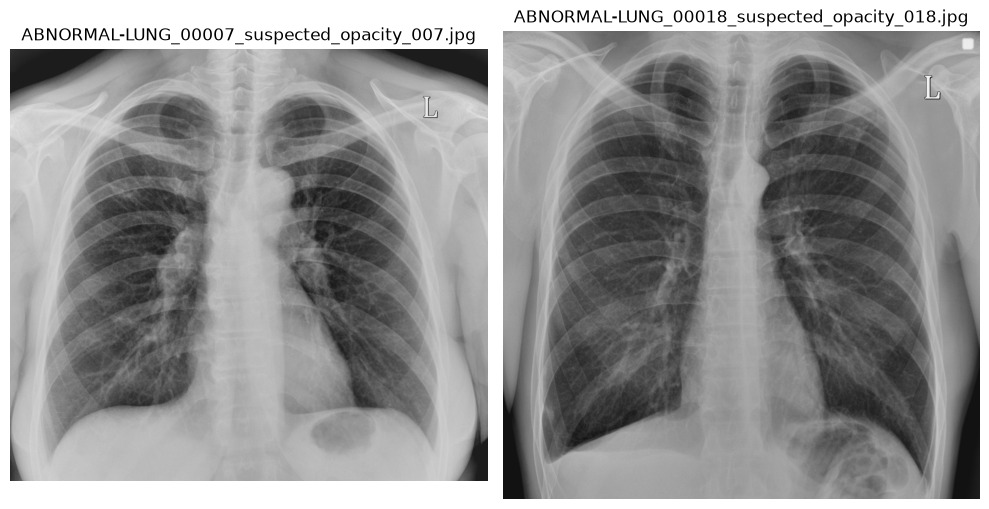

In [22]:
images = [
    "ABNORMAL-LUNG_00007_suspected_opacity_007.jpg",
    "ABNORMAL-LUNG_00018_suspected_opacity_018.jpg",
]

PATH_IMG = Path('..') / 'data' / 'brutes'

fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))

for ax, filename in zip(axes, images):
    img = Image.open(PATH_IMG / filename)
    ax.imshow(img, cmap="gray")
    ax.set_title(filename)
    ax.axis("off")

plt.legend()
plt.tight_layout()
plt.show()

L'image ID 7 est très clair par rapport au autres. Pareil pour celles mal classifé en normal

In [24]:
print(df.columns.tolist())
print(df.head(2))

['case_id', 'run_id', 'evaluation_id', 'prompt_id', 'prompt_name', 'prompt_version', 'ground_truth_label', 'predicted_class', 'confidence', 'latency']
   case_id  run_id  evaluation_id  prompt_id prompt_name prompt_version  \
0       17       1              1          1    baseline             v0   
1       29      83             83          1    baseline             v0   

  ground_truth_label predicted_class  confidence  latency  
0  suspected_opacity          normal        0.95    52971  
1  suspected_opacity          normal        0.95    35864  


In [ ]:
import os
import numpy as np
from PIL import Image
import pandas as pd

BASE = Path('..') / 'data' / 'brutes'

# Mapping case_id -> fichier
id_to_file = {}
for f in os.listdir(BASE):
    parts = f.split('_')
    case_id = int(parts[1])  # ex: "00417" -> 417
    id_to_file[case_id] = f

def analyze_brightness(image_path):
    try:
        img = Image.open(image_path).convert("L")
        arr = np.array(img)
        return {
            "mean_brightness": arr.mean(),
            "std_brightness": arr.std(),
            "p10": np.percentile(arr, 10),
            "p90": np.percentile(arr, 90),
        }
    except:
        return {"mean_brightness": None, "std_brightness": None, "p10": None, "p90": None}

results = []
for _, row in df.iterrows():
    filename = id_to_file.get(row["case_id"])
    if filename is None:
        continue
    stats = analyze_brightness(BASE / filename)
    stats["case_id"] = row["case_id"]
    stats["ground_truth_label"] = row["ground_truth_label"]
    stats["predicted_class"] = row["predicted_class"]
    stats["correct"] = row["ground_truth_label"] == row["predicted_class"]
    results.append(stats)

df_bright = pd.DataFrame(results)
df_bright

,mean_brightness,std_brightness,p10,p90,case_id,ground_truth_label,predicted_class,correct
0,132.297522,35.857077,81.0,165.0,17,suspected_opacity,normal,False
1,126.198231,40.701361,68.0,172.0,29,suspected_opacity,normal,False
2,116.680164,39.846513,68.0,157.0,34,suspected_opacity,normal,False
3,132.806435,37.925475,73.0,173.0,37,suspected_opacity,normal,False
4,123.233150,38.367391,67.0,167.0,72,suspected_opacity,normal,False
...,...,...,...,...,...,...,...,...
245,126.577165,37.999958,69.0,168.0,622,normal,normal,True
246,129.217918,36.536841,80.0,170.0,648,normal,normal,True
247,134.269597,42.941127,73.0,183.0,670,normal,suspected_opacity,False
248,118.501578,30.507859,73.0,150.0,701,normal,normal,True


In [ ]:
df_bright.groupby(["ground_truth_label", "correct"])["mean_brightness"].describe()

count        mean        std         min  \
ground_truth_label correct                                             
normal             False      5.0  115.282141  18.560783   96.203660   
                   True     119.0  120.628921  12.557715   96.203660   
suspected_opacity  False    113.0  130.328435  13.851177   98.706196   
                   True      13.0  137.700987  19.597634  106.896335   

                                   25%         50%         75%         max  
ground_truth_label correct                                                  
normal             False     96.203660  117.594505  132.139284  134.269597  
                   True     111.819292  119.439042  128.072360  151.985897  
suspected_opacity  False    122.039260  129.204079  138.461537  168.090696  
                   True     120.732470  137.621618  154.584802  165.282407

La luminosité est en moyenne la même pour les images bien et mal classifiés

### La taille de l'image a-t-elle un impacte sur la calssification ?

In [ ]:
import os
from pathlib import Path
import numpy as np
from PIL import Image
import pandas as pd

BASE = Path('..') / 'data' / 'brutes'

# Mapping case_id -> fichier
id_to_file = {}
for f in os.listdir(BASE):
    parts = f.split('_')
    case_id = int(parts[1])
    id_to_file[case_id] = f

def analyze_size(image_path):
    img = Image.open(image_path)
    return {
        "width": img.size[0],
        "height": img.size[1],
        "mode": img.mode,
    }

# Appliqué sur tous les cas
results = []
for case_id in df['case_id']:
    if case_id not in id_to_file:
        print(f"case_id {case_id} : fichier introuvable")
        continue
    try:
        info = analyze_size(BASE / id_to_file[case_id])
        info["case_id"] = case_id
        results.append(info)
    except Exception as e:
        print(f"case_id {case_id} : erreur {e}")

sizes_df = pd.DataFrame(results)
print(sizes_df.describe())  # stats globales (min/max/moyenne width, height)
sizes_df

             width       height     case_id
count   250.000000   250.000000  250.000000
mean   2353.716000  2213.688000  414.204000
std     237.754158   306.151455  250.921311
min    1615.000000  1547.000000    1.000000
25%    2224.000000  2013.000000  185.250000
50%    2376.500000  2215.000000  413.000000
75%    2515.250000  2414.000000  621.500000
max    2822.000000  2953.000000  890.000000


,width,height,mode,case_id
0,2411,2388,RGB,17
1,2314,2202,RGB,29
2,1615,1547,RGB,34
3,2051,1999,RGB,37
4,2247,2083,RGB,72
...,...,...,...,...
245,2378,2090,RGB,622
246,2385,2530,RGB,648
247,2305,2154,RGB,670
248,2292,2003,RGB,701


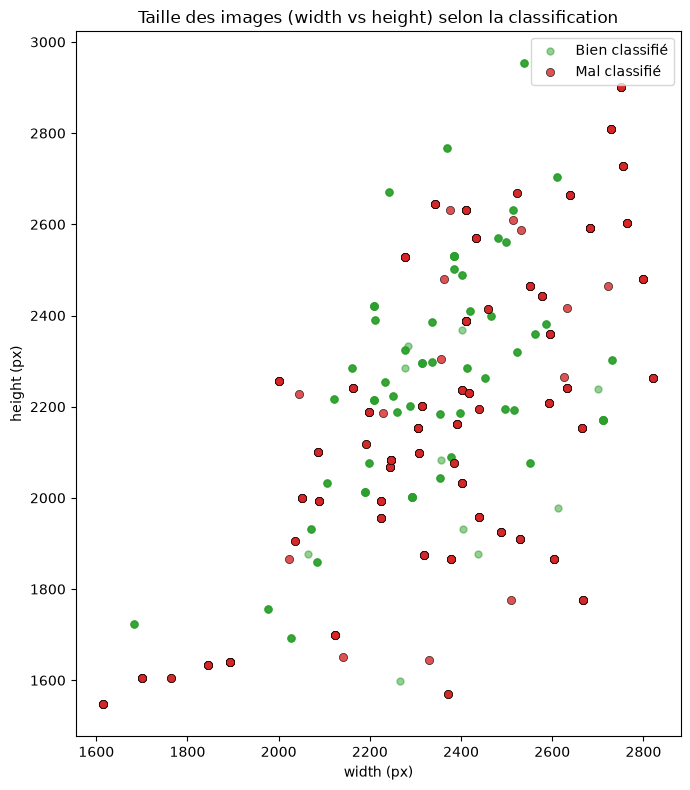

In [10]:

# Récupère les évaluations
evals_df = pd.DataFrame(get_evaluations())

if "correct" not in evals_df.columns:
    evals_df["correct"] = (evals_df["predicted_class"] == evals_df["ground_truth_label"]).astype(int)

# Si un case_id a été évalué avec plusieurs prompts, filtre sur un seul avant de merger
# evals_df = evals_df[evals_df["prompt_id"] == 3]  # décommente et ajuste si besoin

# Merge avec les tailles
merged = sizes_df.merge(evals_df[["case_id", "correct"]], on="case_id", how="inner")

correct = merged[merged["correct"] == 1]
wrong   = merged[merged["correct"] == 0]

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(correct["width"], correct["height"], c="tab:green", label="Bien classifié", alpha=0.5, s=25)
ax.scatter(wrong["width"],   wrong["height"],   c="tab:red",   label="Mal classifié",  alpha=0.8, s=35, edgecolors="black", linewidths=0.5)

ax.set_xlabel("width (px)")
ax.set_ylabel("height (px)")
ax.set_title("Taille des images (width vs height) selon la classification")
ax.legend()
ax.set_aspect("equal", adjustable="box")  # utile si tu veux repérer les images carrées vs rectangulaires
plt.tight_layout()
plt.show()
correct = merged[merged["correct"] == 1]
wrong   = merged[merged["correct"] == 0]

ax.scatter(correct["case_id"], correct["width"], c="tab:green", label="Bien classifié", alpha=0.6, s=20)
ax.scatter(wrong["case_id"],   wrong["width"],   c="tab:red",   label="Mal classifié",  alpha=0.8, s=30)

ax.set_xlabel("case_id")
ax.set_ylabel("width (px)")
ax.set_title("Taille d'image (width) vs cas, coloré par classification")
ax.legend()
plt.show()

La répartition de la taille et des images bien classifer semble ne montrere aucun lien avec les mauvaises classifications